<a href="https://colab.research.google.com/github/andrewolf80550/AA/blob/main/clasifiSucesosTFM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



CLASIFICACIÓN DE SUCESOS DE SEGURIDAD OPERACIONAL

Información historica de los años 2013 al 2020 de seguridad operacional



In [2]:
import numpy as np
import pandas as pd
df = pd.read_excel('suc.xlsx')
df.head()

,EVESO_ID,NUM_EVESO,DESCRIPCION_EVESO,TIPO_EVESO,SUBTIPO_EVESO,EVENTO_TIERRA,FECHA_EVENTO_DATE,HORA_EVENTO,UNIDAD_NOTIFICACION,UNIDAD_OPERATIVA,...,ESTADO_FASE_ACTUAL,ESTADO_EVESO,INVESTIGADOR,TIPO_AERONAVE,FACTOR,FACTOR.1,CAUSA1,CAUSA2,CAUSA3,EXPLICACIÓN
0,23,00002-2013,En cumplimiento del vuelo NSE8860 que cubría l...,NOPER,Mantenimiento,No,2013-01-20,07:40,SATENA,SATENA,...,Cerrada,Cerrado,DAVID STIVENTAMAYO GONZALEZ,Enlace,/Técnico/Falla sistemas/Otros/Fatiga,Técnico,Falla sistemas,Otros,Fatiga,SIN INFORME FINAL
1,26,00003-2013,EN CUMPLIMIENTO A LA ORDEN DE VUELO 2937 EN LA...,INFO,Mantenimiento,No,2013-04-25,15:30,CACOM-2,CACOM-2,...,Cerrada,Cerrado,JUAN CAMILONUÑEZ CUEVAS,Combate,/Técnico/Falla sistemas/Otros/Fatiga,Técnico,Falla sistemas,Otros,Fatiga,SIN INFORME FINAL
2,28,00005-2013,EL DIA 11 DE MARZO DE 2013 EL HELICOPTERO HUEY...,NOPER,RIPP,No,2013-03-11,10:00,GAORI,GAORI,...,Cerrada,Abierto,DANNYBONILLA CUADROS,Helicopteros,/Técnico/Falla sistemas/Otros/Fatiga,Técnico,Falla sistemas,Otros,Fatiga,SIN INFORME FINAL
3,30,00006-2013,"posterior al aterrrizaje en apy, durante el ta...",INFO,Mantenimiento,No,2013-04-26,12:00,CATAM,CATAM,...,Cerrada,Cerrado,ANDRES FERNANDOMARTINEZ VARGAS,Otras,/Técnico/Falla sistemas/Otros/Fatiga,Técnico,Falla sistemas,Otros,Fatiga,SIN INFORME FINAL
4,33,00007-2013,Durante la comprobacion del sistema de refueli...,NOPER,Mantenimiento,No,2013-05-02,11:25,CATAM,CATAM,...,Cerrada,Cerrado,JOSE LEONARDORUBIO CESPEDES,Otras,/Técnico/Falla sistemas/Otros/Fatiga,Técnico,Falla sistemas,Otros,Fatiga,SIN INFORME FINAL


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3569 entries, 0 to 3568
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   EVESO_ID             3569 non-null   int64         
 1   NUM_EVESO            3569 non-null   object        
 2   DESCRIPCION_EVESO    3569 non-null   object        
 3   TIPO_EVESO           3569 non-null   object        
 4   SUBTIPO_EVESO        3569 non-null   object        
 5   EVENTO_TIERRA        3569 non-null   object        
 6   FECHA_EVENTO_DATE    3569 non-null   datetime64[ns]
 7   HORA_EVENTO          3569 non-null   object        
 8   UNIDAD_NOTIFICACION  3569 non-null   object        
 9   UNIDAD_OPERATIVA     3569 non-null   object        
 10  FASE_OPERACION       3569 non-null   object        
 11  ORDEN_VUELO          3559 non-null   object        
 12  TIPO_AERONAVE_SIIO   3569 non-null   object        
 13  MATRICULA_SIIO       3569 non-nul

In [4]:
df.TIPO_EVESO.value_counts()

,count
TIPO_EVESO,
INFO,2091
NOPER,1287
EVOT,122
Accidente,35
RECIL,28
RELES,6


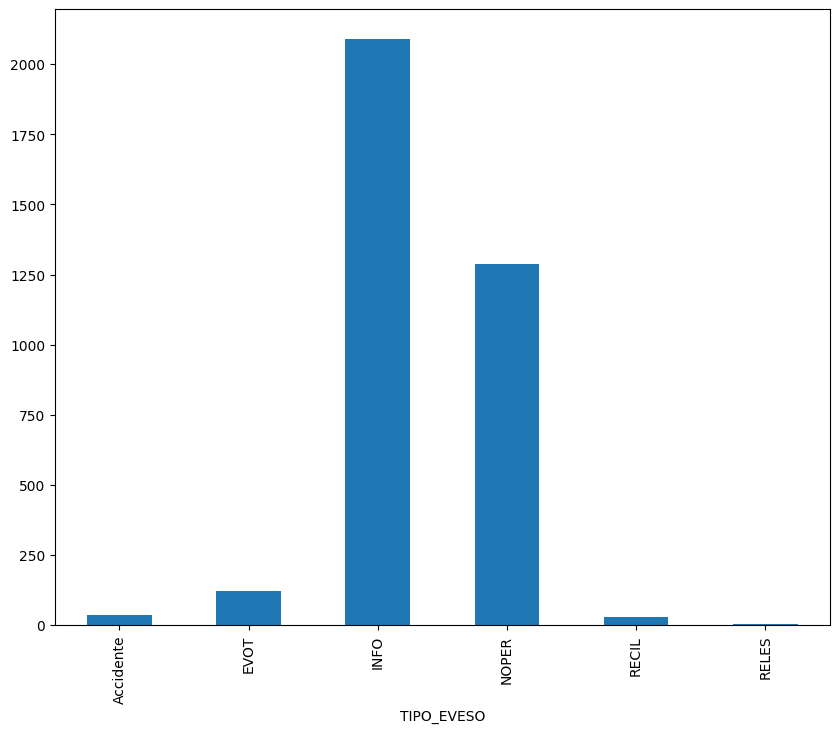

In [5]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(10,8))
df.groupby('TIPO_EVESO').DESCRIPCION_EVESO.count().plot.bar(ylim=0)
plt.show()

CREACIÓN DE DICCIONARIO PARA COMPLETAR LA INFORMACIÓN DE LA COLUMNA SUBTIPO DE EVESO

In [7]:
#dic = {'Mantenimiento': ['falla','mal funcionamiento','motor','winglet','el paracaídas','mantenimiento','sistema','fail','prende','la luz','tren de aterrizaje','RPM','inoperativo','anotaci','desinfla','olor','chip','velocimetro','fisura','escape','sobretorque','encendido','daño','humo','despresuriza','alabeo','asimetria','pierde','potencia','suelta','anormal','generadores','intermitentemente','oxigeno','ruptura','desfase','enciende','fuga','MANIFOLD PRESSURE','burbuja','vuelo de prueba','circuitos', 'deformaci','hidrauli',' inestabilidad','tren asegurado','perdida control direccional','tren no sube','perdida pontencia','restriccion','temperatura','luz de palanca','flaps','detector'],
#      'GAAP': ['colisión','rayadura','enganchada','estrellar','raspar','GAAP'],
#       'BASH': ['ave tipo','fauna','sangre','murcielago','garza','torcaza','caica','chulo','paloma','golondrina','gallinazo','pajaro','gavilan','bandada','golpe','borde ataque','impact'],
#       'RIPP': ['incursión', 'incursion','ingreso','ingreso','carro','pista','calle de rodaje','no autorizado'],
#        'CFIT-ALAR': ['vuelo controlado','terreno','terrain','alarma','confinada','aterrizaje fuerte','positiv'],
#        'MACA': ['resolution advisory','tcas','las dos','air prox','maniobra evasiva','realiza maniobra'],
#       'Impacto Fuego enemigo':['bala', 'proyectil', 'disparo', 'orificio','ataque','terrorista','hostigan','calibre','fuego enemigo','mision alfa'],
#        'Mercancias Peligrosas': ['derrame','olor','aceite','fluido','quimico','combustible'],
#       'LOC': ['engelamiento','perdida de control','congelamiento','destruida','precipita a tierra','accident','se accidenta','fallecen','muertos'],
#        'Armamento': ['armamento', 'bomba', 'carchucho','explosivos','atentado','calibre','booster','entrega']}

In [8]:
dic = {'Mantenimiento': ['falla','mal funcionamiento','motor','winglet','el paracaídas','mantenimiento','sistema','fail','prende','la luz','tren de aterrizaje','RPM','inoperativo','anotaci','desinfla','olor','chip','velocimetro','fisura','escape','sobretorque','encendido','daño','humo','despresuriza','alabeo','asimetria','pierde','potencia','suelta','anormal','generadores','intermitentemente','oxigeno','ruptura','desfase','enciende','fuga','MANIFOLD PRESSURE','burbuja','vuelo de prueba','circuitos', 'deformaci','hidrauli',' inestabilidad','tren asegurado','perdida control direccional','tren no sube','perdida pontencia','restriccion','temperatura','luz de palanca','flaps','detector'],
      'GAAP': ['colisión','rayadura','enganchada','estrellar','raspar','GAAP'],
       'BASH': ['ave tipo','fauna','sangre','murcielago','garza','torcaza','caica','chulo','paloma','golondrina','gallinazo','pajaro','gavilan','bandada','golpe','borde ataque','impact'],
       'RIPP': ['incursión', 'incursion','ingreso','ingreso','carro','pista','calle de rodaje','no autorizado'],
        'CFIT-ALAR': ['vuelo controlado','terreno','terrain','alarma','confinada','aterrizaje fuerte','positiv'],
        'MACA': ['resolution advisory','tcas','las dos','air prox','maniobra evasiva','realiza maniobra'],
#       'Impacto Fuego enemigo':['bala', 'proyectil', 'disparo', 'orificio','ataque','terrorista','hostigan','calibre','fuego enemigo','mision alfa'],
        'Mercancias Peligrosas': ['derrame','olor','aceite','fluido','quimico','combustible'],
#       'LOC': ['engelamiento','perdida de control','congelamiento','destruida','precipita a tierra','accident','se accidenta','fallecen','muertos'],
        'Armamento': ['armamento', 'bomba', 'carchucho','explosivos','atentado','calibre','booster','entrega']}

In [9]:
for k in dic:
    for p in dic[k]:
        df['DESCRIPCION_EVESO'].filter(like= p)
        df['SUBTIPO_EVESO'] = np.where(df['DESCRIPCION_EVESO'].str.contains( p, case=False),k, df['SUBTIPO_EVESO'])

In [10]:
df.SUBTIPO_EVESO.value_counts()

,count
SUBTIPO_EVESO,
Mantenimiento,1562
RIPP,559
BASH,526
Mercancias Peligrosas,409
CFIT-ALAR,136
<Sin Valor>,110
Armamento,98
MACA,77
GAAP,67


In [11]:
df.head()

,EVESO_ID,NUM_EVESO,DESCRIPCION_EVESO,TIPO_EVESO,SUBTIPO_EVESO,EVENTO_TIERRA,FECHA_EVENTO_DATE,HORA_EVENTO,UNIDAD_NOTIFICACION,UNIDAD_OPERATIVA,...,ESTADO_FASE_ACTUAL,ESTADO_EVESO,INVESTIGADOR,TIPO_AERONAVE,FACTOR,FACTOR.1,CAUSA1,CAUSA2,CAUSA3,EXPLICACIÓN
0,23,00002-2013,En cumplimiento del vuelo NSE8860 que cubría l...,NOPER,Mantenimiento,No,2013-01-20,07:40,SATENA,SATENA,...,Cerrada,Cerrado,DAVID STIVENTAMAYO GONZALEZ,Enlace,/Técnico/Falla sistemas/Otros/Fatiga,Técnico,Falla sistemas,Otros,Fatiga,SIN INFORME FINAL
1,26,00003-2013,EN CUMPLIMIENTO A LA ORDEN DE VUELO 2937 EN LA...,INFO,Mercancias Peligrosas,No,2013-04-25,15:30,CACOM-2,CACOM-2,...,Cerrada,Cerrado,JUAN CAMILONUÑEZ CUEVAS,Combate,/Técnico/Falla sistemas/Otros/Fatiga,Técnico,Falla sistemas,Otros,Fatiga,SIN INFORME FINAL
2,28,00005-2013,EL DIA 11 DE MARZO DE 2013 EL HELICOPTERO HUEY...,NOPER,Mercancias Peligrosas,No,2013-03-11,10:00,GAORI,GAORI,...,Cerrada,Abierto,DANNYBONILLA CUADROS,Helicopteros,/Técnico/Falla sistemas/Otros/Fatiga,Técnico,Falla sistemas,Otros,Fatiga,SIN INFORME FINAL
3,30,00006-2013,"posterior al aterrrizaje en apy, durante el ta...",INFO,Mantenimiento,No,2013-04-26,12:00,CATAM,CATAM,...,Cerrada,Cerrado,ANDRES FERNANDOMARTINEZ VARGAS,Otras,/Técnico/Falla sistemas/Otros/Fatiga,Técnico,Falla sistemas,Otros,Fatiga,SIN INFORME FINAL
4,33,00007-2013,Durante la comprobacion del sistema de refueli...,NOPER,Mantenimiento,No,2013-05-02,11:25,CATAM,CATAM,...,Cerrada,Cerrado,JOSE LEONARDORUBIO CESPEDES,Otras,/Técnico/Falla sistemas/Otros/Fatiga,Técnico,Falla sistemas,Otros,Fatiga,SIN INFORME FINAL


In [12]:
from io import StringIO
col = ['SUBTIPO_EVESO','DESCRIPCION_EVESO',]
df = df[col]
df = df[pd.notnull(df['DESCRIPCION_EVESO'])]
df.columns = ['SUBTIPO_EVESO', 'DESCRIPCION_EVESO']
df['category_id'] = df['SUBTIPO_EVESO'].factorize()[0]
category_id_df = df[['SUBTIPO_EVESO', 'category_id']].drop_duplicates().sort_values('category_id')
category_to_id = dict(category_id_df.values)
id_to_category = dict(category_id_df[['category_id', 'SUBTIPO_EVESO']].values)
df.head()

,SUBTIPO_EVESO,DESCRIPCION_EVESO,category_id
0,Mantenimiento,En cumplimiento del vuelo NSE8860 que cubría l...,0
1,Mercancias Peligrosas,EN CUMPLIMIENTO A LA ORDEN DE VUELO 2937 EN LA...,1
2,Mercancias Peligrosas,EL DIA 11 DE MARZO DE 2013 EL HELICOPTERO HUEY...,1
3,Mantenimiento,"posterior al aterrrizaje en apy, durante el ta...",0
4,Mantenimiento,Durante la comprobacion del sistema de refueli...,0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3569 entries, 0 to 3568
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   SUBTIPO_EVESO      3569 non-null   object
 1   DESCRIPCION_EVESO  3569 non-null   object
 2   category_id        3569 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 83.8+ KB


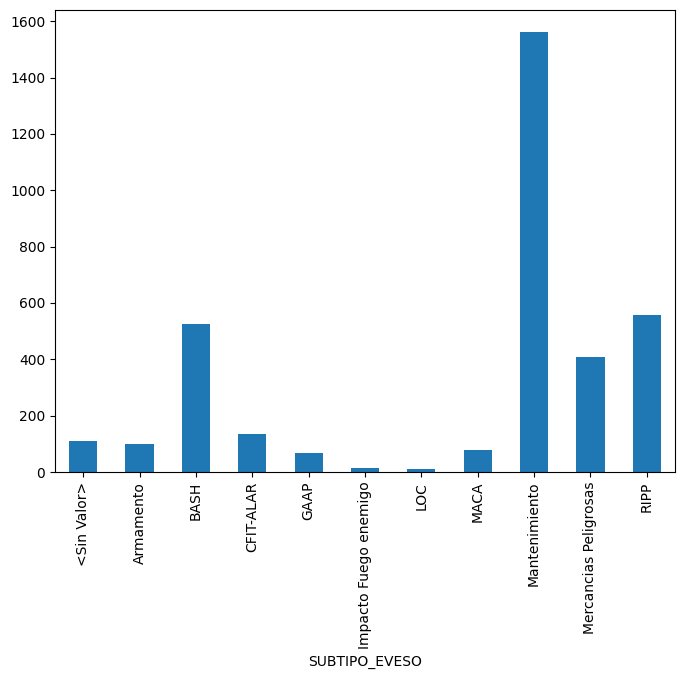

In [14]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(8,6))
df.groupby('SUBTIPO_EVESO').DESCRIPCION_EVESO.count().plot.bar(ylim=0)
plt.show()

In [15]:
df.SUBTIPO_EVESO.value_counts()

,count
SUBTIPO_EVESO,
Mantenimiento,1562
RIPP,559
BASH,526
Mercancias Peligrosas,409
CFIT-ALAR,136
<Sin Valor>,110
Armamento,98
MACA,77
GAAP,67


In [16]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk import word_tokenize
from nltk.data import load
from nltk.stem import SnowballStemmer
from string import punctuation
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
spanish_stopwords = stopwords.words('spanish')
stemmer = SnowballStemmer('spanish')
non_words = list(punctuation)
non_words.extend(['¿', '¡'])
non_words.extend(map(str,range(25)))
stemmer = SnowballStemmer('spanish')
def stem_tokens(tokens, stemmer):
    stemmed = []
    for item in tokens:
        stemmed.append(stemmer.stem(item))
    return stemmed
def tokenize(text):
    text = 'DESCRIPCION_EVESO'.join([c for c in text if c not in non_words])
    tokens =  word_tokenize(text)
    # stem
    try:
        stems = stem_tokens(tokens, stemmer)
    except Exception as e:
        print(e)
        print(text)
        stems = ['']
    return stems
vectorizer = CountVectorizer(
                analyzer = 'word',
                tokenizer = tokenize,
                lowercase = True,
                stop_words = spanish_stopwords)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [17]:
tfidf = TfidfVectorizer(sublinear_tf=True, min_df=5, norm='l2', encoding='latin-1', ngram_range=(1, 2),)

In [18]:
features = tfidf.fit_transform(df.DESCRIPCION_EVESO).toarray()
labels = df.category_id

In [19]:
print (labels)

0       0
1       1
2       1
3       0
4       0
       ..
3564    1
3565    1
3566    4
3567    6
3568    2
Name: category_id, Length: 3569, dtype: int64


In [20]:
features.shape

(3569, 8740)

Se utiliza chi2 para encontrar las palabras relacionadas por cada clasificación

In [22]:
from sklearn.feature_selection import chi2
import numpy as np
N=5
for SUBTIPO_EVESO, category_id in sorted(category_to_id.items()):
  features_chi2 = chi2(features, labels == category_id)
  indices = np.argsort(features_chi2[0])
  feature_names = np.array(tfidf.get_feature_names())[indices]
  unigrams = [v for v in feature_names if len(v.split(' ')) == 1]
  bigrams = [v for v in feature_names if len(v.split(' ')) == 2]
print("'{}':".format(SUBTIPO_EVESO))
print("Unigramas mas correlacionados:\n. {}".format('\n. '.join(unigrams[-N:])))
print("Bigramas mas correlacionados:\n. {}".format('\n. '.join(bigrams[-N:])))

AttributeError: 'TfidfVectorizer' object has no attribute 'get_feature_names'

## Clasificador

* El entrenamiento del clasificiador requiere la transformación de la descripción de los eventos de seguridad en vectores de números. Para ello se emplea la representación de los vectores como vectores ponderados TF-IDF

* luego de ello es posible entrenar el algoritmo con la descripción y que este logre predecir el subtipo de eveso al cual corresponde.

primer algoritmo para prueba es el Naive Bayes Classifier, este trabaja con el conteo de palabras es la variante multinomial.

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.svm import LinearSVC
#from sklearn.naive_bayes import MultinomialNB

X_train, X_test, y_train, y_test = train_test_split(df['DESCRIPCION_EVESO'], df['SUBTIPO_EVESO'], random_state = 0)
count_vect = CountVectorizer()
X_train_counts = count_vect.fit_transform(X_train)
tfidf_transformer = TfidfTransformer()
X_train_tfidf = tfidf_transformer.fit_transform(X_train_counts)

clf = LinearSVC().fit(X_train_tfidf, y_train)

In [24]:
print(clf.predict(count_vect.transform(["AC 2250 FINALIZANDO UNA MISIÓN DE ENTRENAMIENTO TRANSICIÓN, DURANTE UN TRÁFICO RECTANGULAR SE BAJÁ EL TREN POR EL SISTEMA NORMAL Y ÉSTE BAJA Y ASEGURA MOSTRANDO LAS 3 LUCES VERDES Y EL SONIDO POSITIVO DEL BEEP, AL RECHEQUEO EL TREN EN FINAL SE NOTA QUE LA LUZ DEL TREN DE NARIZ SE HA APAGADO Y EL BEEP YA NO SUENA, EL PILOTO INSTRUCTOR TOMA EL CONTROL DEL AVIÓN, Y ASCIENDE A 3000FT EN LA P-29 Y DECIDE BAJAR EL TREN POR EL SISTEMA NORMAL EL CUAL BAJA Y ASEGURA CON LAS 3 LUCES VERDES Y EL BEEP, PERO DESPUÉS DE 23 SEGUNDOS DE HABER BAJADO EL TREN LA LUZ DEL TREN DE NARIZ SE APAGA Y EL BEEP YA NO SUENA, EN ESE MOMENTO LA TRIPULACION BAJA EL TREN POR EMERGENCIA Y NUEVAMENTE ASEGURA EL TREN MOSTRANDO LAS 3 LUCES VERDES Y SONIDO BEEP, FINALMENTE LA TRIPULACION SOLICITO ATERRIZAR Y EN FINAL LARGA SE BAJA EL TREN POR EL SISTEMA NORMAL EL CUAL ASEGURA Y SEGUIDAMENTE SE ACCIONA LA PALANCA POR EMERGENCIA ATERRIZANDO DE ESTA FORMA Y CHEQUEANDO TODO EL TIEMPO LAS TRES LUCES VERDES Y EL BEEP HASTA EL ATERRIZAJE. SE EFECTUA LA ANOTACION EN EL LIBRO DE MANTENIMIENTO."])))

['CFIT-ALAR']


In [25]:
print(clf.predict(count_vect.transform(["El carro de bomberos ingresa a la pista sin autorización"])))

['RIPP']


In [26]:
print(clf.predict(count_vect.transform(["El tren de aterrizaje no muestra las luces verdes que corresponden a que se encuentra asegurado"])))

['Mantenimiento']


In [27]:
print(clf.predict(count_vect.transform(["EN VUELO CRUCERO SE DETECTA OTRA AERONAVE Y SE PROCEDE CON LA MANIOBRA EVASIVA INFORMANDO AL CONTROLADOR"])))

['MACA']


In [28]:
print(clf.predict(count_vect.transform(["ave tipo garza roza plano izquierdo de al aeronave."])))

['BASH']


In [29]:

df[df['DESCRIPCION_EVESO'] == "Aeronave B 206 Ranger presenta indicacion de luz de chip detector del motor durante turno de entrenamiento, la aeronave aterriza en el CACOM 4 y apaga sin novedad, se toman muestras de aceite del motor pendiente resultados."]

,SUBTIPO_EVESO,DESCRIPCION_EVESO,category_id
15,Mercancias Peligrosas,Aeronave B 206 Ranger presenta indicacion de l...,1


In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score

In [31]:
models = [RandomForestClassifier(n_estimators=200, max_depth=30, random_state=0),LinearSVC(),LogisticRegression(random_state=0),]
CV = 5
cv_df = pd.DataFrame(index=range(CV * len(models)))
entries = []
for model in models:
  model_name = model.__class__.__name__
  accuracies = cross_val_score(model, features, labels, scoring='accuracy', cv=CV)
  for fold_idx, accuracy in enumerate(accuracies):
    entries.append((model_name, fold_idx, accuracy))
cv_df = pd.DataFrame(entries, columns=['model_name', 'fold_idx', 'accuracy'])

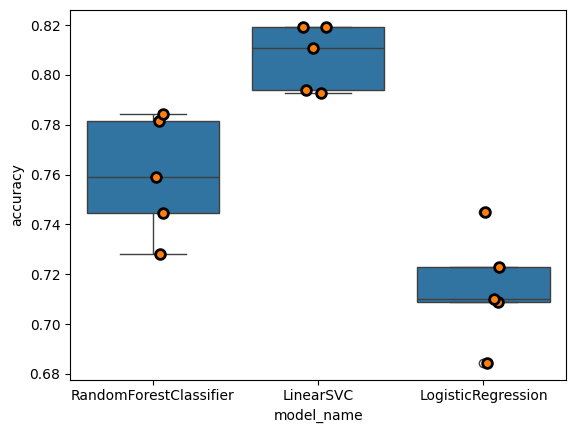

In [32]:
import seaborn as sns
sns.boxplot(x='model_name', y='accuracy', data=cv_df)
sns.stripplot(x='model_name', y='accuracy', data=cv_df,size=7, jitter=True, edgecolor="Black", linewidth=2)
plt.show()

In [34]:
cv_df.groupby('model_name').accuracy.mean()

,accuracy
model_name,
LinearSVC,0.807225
LogisticRegression,0.714197
RandomForestClassifier,0.759592


In [35]:
from sklearn.model_selection import train_test_split
model = LinearSVC()
X_train, X_test, y_train, y_test, indices_train, indices_test = train_test_split(features, labels, df.index, test_size=0.33, random_state=0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

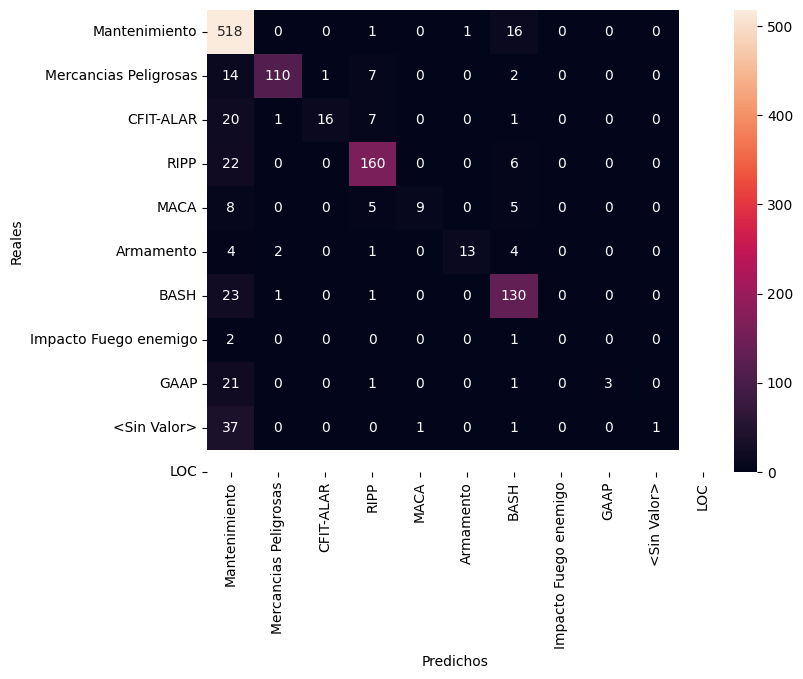

In [36]:
from sklearn.metrics import confusion_matrix
conf_mat = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(conf_mat, annot=True, fmt='d',xticklabels=category_id_df.SUBTIPO_EVESO.values, yticklabels=category_id_df.SUBTIPO_EVESO.values)
plt.ylabel('Reales')
plt.xlabel('Predichos')
plt.show()

In [37]:
from IPython.display import display
for predichos in category_id_df.category_id:
  for actual in category_id_df.category_id:
    if predichos != actual and conf_mat[actual,predichos] >= 10:
      print("'{}' PREDICHOS COMO '{}' : {} EJEMPLOS.".format(id_to_category[actual], id_to_category[predichos], conf_mat[actual, predichos]))
      display(df.loc[indices_test[(y_test == actual) & (y_pred == predichos)]][['SUBTIPO_EVESO', 'DESCRIPCION_EVESO']])
      print('---------------------------------------------------------------------------------------')

'Mercancias Peligrosas' PREDICHOS COMO 'Mantenimiento' : 14 EJEMPLOS.


,SUBTIPO_EVESO,DESCRIPCION_EVESO
1662,Mercancias Peligrosas,Durante mision PHI - OPERACION DE ILUMINACION...
3198,Mercancias Peligrosas,Durante misión de instrucción en la ruta SKPQ ...
1962,Mercancias Peligrosas,"Durante misión TANGO, al finalizar demostració..."
2875,Mercancias Peligrosas,Aeronave C-130 matricula FAC 1001 durante pren...
3124,Mercancias Peligrosas,"Aeronave despegó en la ruta SKUA-SKYP, durant..."
572,Mercancias Peligrosas,Durante fase de aterrizaje el FAC 3054 present...
2500,Mercancias Peligrosas,El helicóptero B-212 FAC4021 durante misión QU...
2983,Mercancias Peligrosas,Durante misión de escolta aérea aeronave B-212...
3132,Mercancias Peligrosas,AERONAVE POSTERIOR A CUMPLIMIENTO MISION KILO ...
1739,Mercancias Peligrosas,"BLART SKSA, FAC6057 ART Night Eagle, durante e..."


---------------------------------------------------------------------------------------
'CFIT-ALAR' PREDICHOS COMO 'Mantenimiento' : 20 EJEMPLOS.


,SUBTIPO_EVESO,DESCRIPCION_EVESO
3568,CFIT-ALAR,Aeronave T-27 FAC 2256 En cumplimiento vuelo d...
1789,CFIT-ALAR,Aeronave A29B FAC 3104 misión instrucción inst...
2858,CFIT-ALAR,Aeronave T-27 FAC 2252 en misión de entrenamie...
398,CFIT-ALAR,aeronave en entrenamiento de tactico presenta ...
436,CFIT-ALAR,DURANTE CUMPLIMIENTO A ORDEN DE VUELO 747 MISI...
1519,CFIT-ALAR,Reporte de aterrizaje fuerte por parte de la t...
3234,CFIT-ALAR,Aeronave despego en la ruta SKTQ-AREA-SKTQ en ...
692,CFIT-ALAR,Durante la aproximacion final a los helipuert...
2583,CFIT-ALAR,Posterior escolta col 6 una vez configuración...
23,CFIT-ALAR,EN CUMPLIMIENTO A LA ORDEN DE VUELO 3796 DURAN...


---------------------------------------------------------------------------------------
'RIPP' PREDICHOS COMO 'Mantenimiento' : 22 EJEMPLOS.


...

,SUBTIPO_EVESO,DESCRIPCION_EVESO
192,GAAP,"En cumplimiento a la orden de vuelo n.1645, el..."
3253,GAAP,"Posterior a desarrollo de misión EPSYLON, en l..."
2802,GAAP,"En cumplimiento a orden de vuelo No 978963, po..."
2601,GAAP,Durante postvuelo posterior a una misión de in...
1806,GAAP,"Aeronave A29B FAC 3118, misión de entrenamient..."
2258,GAAP,Posterior al despegue misión MAXIM en la ruta ...
483,GAAP,"Posterior decolaje en mision de instruccion , ..."
1246,GAAP,Durante la fase de ascenso del FAC 1204 (B-727...
3550,GAAP,"En cumplimiento de mision ANGEL-2, Posterior a..."
2070,GAAP,Durante misión EPSYLON en desarrollo de ejerci...


---------------------------------------------------------------------------------------
'<Sin Valor>' PREDICHOS COMO 'Mantenimiento' : 37 EJEMPLOS.


,SUBTIPO_EVESO,DESCRIPCION_EVESO
3020,<Sin Valor>,Durante misión EPSYLON el piloto baja palanca ...
2702,<Sin Valor>,"Aeronave T-27 FAC 2254, en cumplimiento mision..."
545,<Sin Valor>,Aeronave FAC 1208 efectuó ruta BAQ-APY. Durant...
1760,<Sin Valor>,Me permito informar realizando PMD del AH-60 F...
463,<Sin Valor>,Durante la prevuelo de la cabina del FAC-5057 ...
817,<Sin Valor>,"Durante la ruta Bogota – Rionegro, el C-208 FA..."
1059,<Sin Valor>,Durante pruebas del gancho de carga para una m...
2615,<Sin Valor>,"INFO de T-90 FAC 2455, misión sigma durante l..."
1603,<Sin Valor>,DURANTE EL DESARROLLO DE UNA MISIÓN DE TRANSPO...
1311,<Sin Valor>,Aeronave FAC 3049 KFIR durante misión de entre...


---------------------------------------------------------------------------------------


IndexError: index 10 is out of bounds for axis 0 with size 10

In [40]:
model.fit(features, labels)

LinearSVC()

In [41]:
from sklearn.feature_selection import chi2
N = 10
for Product, category_id in sorted(category_to_id.items()):
  indices = np.argsort(model.coef_[category_id])
  feature_names = np.array(tfidf.get_feature_names())[indices]
  unigrams = [v for v in reversed(feature_names) if len(v.split(' ')) == 1][:N]
  bigrams = [v for v in reversed(feature_names) if len(v.split(' ')) == 2][:N]
  print("# '{}':".format(Product))
  print("  . Top unigrams:\n       . {}".format('\n       . '.join(unigrams)))
  print("  . Top bigrams:\n       . {}".format('\n       . '.join(bigrams)))

AttributeError: 'TfidfVectorizer' object has no attribute 'get_feature_names'

In [42]:
texts = ["durante el despegue se presenta, golpe con aves",
         "EN VUELO SE DERRAMO LAS MUESTRAS DEL ACEITE",
         "el carro de bomberos ingreso a la pista sin autorización",
         "Durante la operacion de vuelo se desprende la tapa del combustible",
         "la aeronave observo otra en la misma trayectoria y decide realizar maniobra evasiva",
         "la aeronave se encontraba en vuelo y fallo el altimetro",
         "paloma choca contra el motor principal",
         "se observa orificio de bala en el fuselaje de la aeronave",
         "durante el rodaje la aeronave presenta iluminación luz engine chip"
         ]
text_features = tfidf.transform(texts)
predictions = model.predict(text_features)
for text, predicted in zip(texts, predictions):
  print('"{}"'.format(text))
  print("  - Predicted as: '{}'".format(id_to_category[predicted]))
  print("")

"durante el despegue se presenta, golpe con aves"
  - Predicted as: 'BASH'

"EN VUELO SE DERRAMO LAS MUESTRAS DEL ACEITE"
  - Predicted as: 'Mercancias Peligrosas'

"el carro de bomberos ingreso a la pista sin autorización"
  - Predicted as: 'RIPP'

"Durante la operacion de vuelo se desprende la tapa del combustible"
  - Predicted as: 'Mercancias Peligrosas'

"la aeronave observo otra en la misma trayectoria y decide realizar maniobra evasiva"
  - Predicted as: 'MACA'

"la aeronave se encontraba en vuelo y fallo el altimetro"
  - Predicted as: 'Mantenimiento'

"paloma choca contra el motor principal"
  - Predicted as: 'BASH'

"se observa orificio de bala en el fuselaje de la aeronave"
  - Predicted as: 'BASH'

"durante el rodaje la aeronave presenta iluminación luz engine chip"
  - Predicted as: 'Mantenimiento'



In [43]:
from sklearn import metrics
print(metrics.classification_report(y_test, y_pred, target_names=df['SUBTIPO_EVESO'].unique()))

ValueError: Number of classes, 10, does not match size of target_names, 11. Try specifying the labels parameter